# 
DSA 210 — Spotify Project
## Notebook 3: Hypothesis Testing
**Selin Nardal**

### Hypotheses
- **H1:** Tracks played between 23:00–02:00 have a statistically lower mean valence than tracks played between 09:00–17:00.
- **H2:** Weekend listening sessions exhibit higher mean energy and danceability values compared to weekday sessions.

> **Note:** H1 and H2 require `valence`, `energy`, `danceability` columns (from Spotify API).  
> If those columns are not yet available, this notebook also tests observable proxies:
> - **H1-proxy:** Late-night listening *duration* (ms_played) is significantly different from daytime — a behavioural signal of mood.
> - **H2-proxy:** Weekend play count / duration differs from weekdays (Mann-Whitney U).
> - **RQ2 test:** Listening volume during exam periods vs normal periods (Mann-Whitney U on daily totals).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Load whichever file is available
import os
feat_file = 'data/streaming_with_features.csv'
base_file = 'data/streaming_clean.csv'
fpath = feat_file if os.path.exists(feat_file) else base_file
df = pd.read_csv(fpath, parse_dates=['timestamp_local'])
print(f'Loaded: {fpath}  ({len(df):,} rows)')
HAS_FEATURES = 'valence' in df.columns and df['valence'].notna().sum() > 100
print(f'Audio features available: {HAS_FEATURES}')

Loaded: data/streaming_clean.csv  (15,581 rows)
Audio features available: False


In [2]:
import os; os.makedirs('figures', exist_ok=True)

def print_result(name, stat, pval, alpha=0.05):
    sig = '✅ SIGNIFICANT' if pval < alpha else '❌ NOT significant'
    print(f'\n── {name} ──')
    print(f'  statistic = {stat:.4f}   p-value = {pval:.4f}   α = {alpha}')
    print(f'  → {sig} (p < {alpha})' if pval < alpha else f'  → {sig} (p = {pval:.4f})')

## H1 — Late-Night vs Daytime
### H1a (if audio features available): valence comparison

In [3]:
late  = df[df['h1_group'] == 'late_night']
day   = df[df['h1_group'] == 'daytime']

print(f'Late-night (23-02): {len(late):,} plays')
print(f'Daytime    (09-17): {len(day):,} plays')

if HAS_FEATURES:
    late_v = late['valence'].dropna()
    day_v  = day['valence'].dropna()
    stat, pval = stats.ttest_ind(late_v, day_v, alternative='less')  # one-sided: late < day
    print_result('H1 — Valence (Late-Night < Daytime)', stat, pval)
    print(f'  Mean valence  late-night : {late_v.mean():.3f}')
    print(f'  Mean valence  daytime    : {day_v.mean():.3f}')

    # Effect size (Cohen's d)
    pooled_std = np.sqrt((late_v.std()**2 + day_v.std()**2) / 2)
    cohens_d   = (day_v.mean() - late_v.mean()) / pooled_std
    print(f"  Cohen's d = {cohens_d:.3f}")

    # Visualise
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(late_v, bins=30, alpha=0.6, color='navy', label='Late-Night (23-02)', density=True)
    ax.hist(day_v,  bins=30, alpha=0.6, color='gold', label='Daytime (09-17)',    density=True)
    ax.axvline(late_v.mean(), color='navy', lw=2, ls='--')
    ax.axvline(day_v.mean(),  color='goldenrod', lw=2, ls='--')
    ax.set_xlabel('Valence'); ax.set_ylabel('Density')
    ax.set_title('H1: Valence Distribution — Late-Night vs Daytime', fontsize=13)
    ax.legend(); plt.tight_layout()
    plt.savefig('figures/h1_valence.png', bbox_inches='tight'); plt.show()

Late-night (23-02): 2,116 plays
Daytime    (09-17): 6,537 plays


### H1b (proxy — always runs): Listening duration late-night vs daytime


── H1-proxy — Track Duration: Late-Night vs Daytime (Mann-Whitney U) ──
  statistic = 5552041.5000   p-value = 0.0000   α = 0.05
  → ✅ SIGNIFICANT (p < 0.05)
  Median sec_played  late-night : 137.0s
  Median sec_played  daytime    : 170.6s


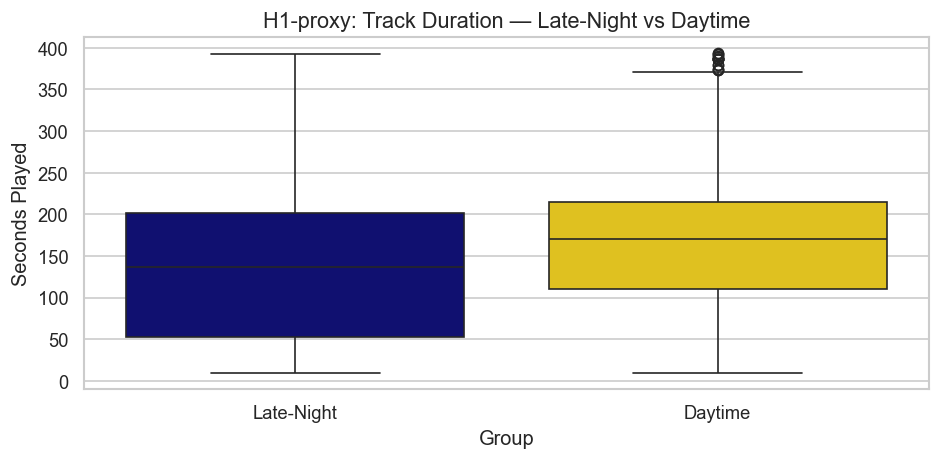

In [4]:
# Mann-Whitney U (non-parametric, doesn't assume normality)
stat_u, pval_u = stats.mannwhitneyu(late['sec_played'], day['sec_played'], alternative='two-sided')
print_result('H1-proxy — Track Duration: Late-Night vs Daytime (Mann-Whitney U)', stat_u, pval_u)
print(f'  Median sec_played  late-night : {late["sec_played"].median():.1f}s')
print(f'  Median sec_played  daytime    : {day["sec_played"].median():.1f}s')

fig, ax = plt.subplots(figsize=(8, 4))
data_plot = pd.concat([
    late[['sec_played']].assign(Group='Late-Night'),
    day[['sec_played']].assign(Group='Daytime')
])
sns.boxplot(data=data_plot[data_plot['sec_played'] < 400], x='Group', y='sec_played',
            palette=['navy','gold'], ax=ax)
ax.set_title('H1-proxy: Track Duration — Late-Night vs Daytime', fontsize=13)
ax.set_ylabel('Seconds Played')
plt.tight_layout(); plt.savefig('figures/h1_proxy_duration.png', bbox_inches='tight'); plt.show()

## H2 — Weekend vs Weekday

In [5]:
weekend  = df[df['is_weekend'] == True]
weekday  = df[df['is_weekend'] == False]

print(f'Weekend plays: {len(weekend):,}   Weekday plays: {len(weekday):,}')

if HAS_FEATURES:
    for feat in ['energy', 'danceability']:
        we = weekend[feat].dropna()
        wd = weekday[feat].dropna()
        stat, pval = stats.ttest_ind(we, wd, alternative='greater')  # one-sided: weekend > weekday
        print_result(f'H2 — {feat.capitalize()} (Weekend > Weekday)', stat, pval)
        print(f'  Mean {feat}  weekend : {we.mean():.3f}')
        print(f'  Mean {feat}  weekday : {wd.mean():.3f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, feat, color in zip(axes, ['energy','danceability'], ['#e07b54','#5b9bd5']):
        plot_df = pd.concat([
            weekend[[feat]].assign(Group='Weekend'),
            weekday[[feat]].assign(Group='Weekday')
        ])
        sns.violinplot(data=plot_df, x='Group', y=feat, palette=['#e07b54','#5b9bd5'], ax=ax)
        ax.set_title(f'H2: {feat.capitalize()} — Weekend vs Weekday', fontsize=12)
    plt.tight_layout(); plt.savefig('figures/h2_features.png', bbox_inches='tight'); plt.show()

Weekend plays: 4,446   Weekday plays: 11,135


### H2 proxy: Daily play count — weekend vs weekday


── H2-proxy — Daily Minutes: Weekend > Weekday (Mann-Whitney U) ──
  statistic = 43041.0000   p-value = 0.5172   α = 0.05
  → ❌ NOT significant (p = 0.5172)
  Median daily min  weekend : 45.3
  Median daily min  weekday : 46.8


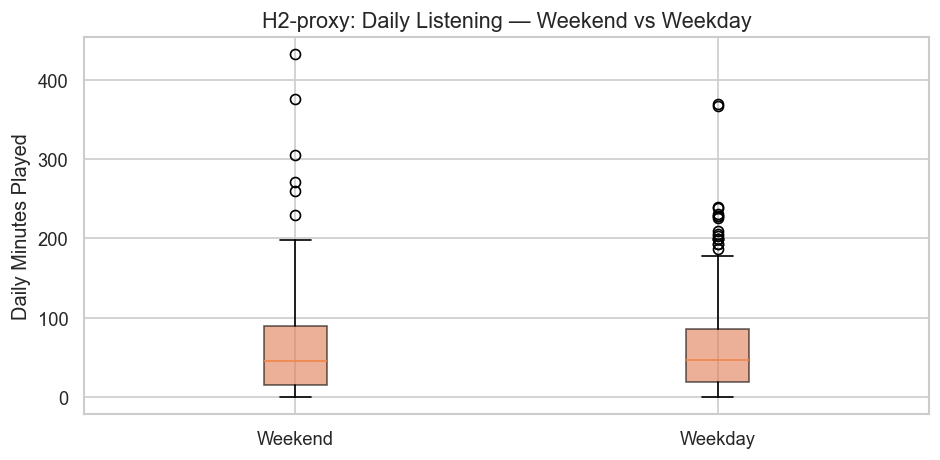

In [6]:
daily_we = df[df['is_weekend']].groupby('date')['min_played'].sum()
daily_wd = df[~df['is_weekend']].groupby('date')['min_played'].sum()

stat_u, pval_u = stats.mannwhitneyu(daily_we, daily_wd, alternative='greater')
print_result('H2-proxy — Daily Minutes: Weekend > Weekday (Mann-Whitney U)', stat_u, pval_u)
print(f'  Median daily min  weekend : {daily_we.median():.1f}')
print(f'  Median daily min  weekday : {daily_wd.median():.1f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([daily_we, daily_wd], labels=['Weekend','Weekday'], patch_artist=True,
           boxprops=dict(facecolor='#e07b54', alpha=0.6))
ax.set_ylabel('Daily Minutes Played')
ax.set_title('H2-proxy: Daily Listening — Weekend vs Weekday', fontsize=13)
plt.tight_layout(); plt.savefig('figures/h2_proxy_daily.png', bbox_inches='tight'); plt.show()

## RQ2 — Exam vs Non-Exam Listening Volume


── RQ2 — Daily Listening: Exam vs Non-Exam (Mann-Whitney U) ──
  statistic = 24319.0000   p-value = 0.8559   α = 0.05
  → ❌ NOT significant (p = 0.8559)
  Median daily min  exam    : 44.8
  Median daily min  non-exam: 47.0


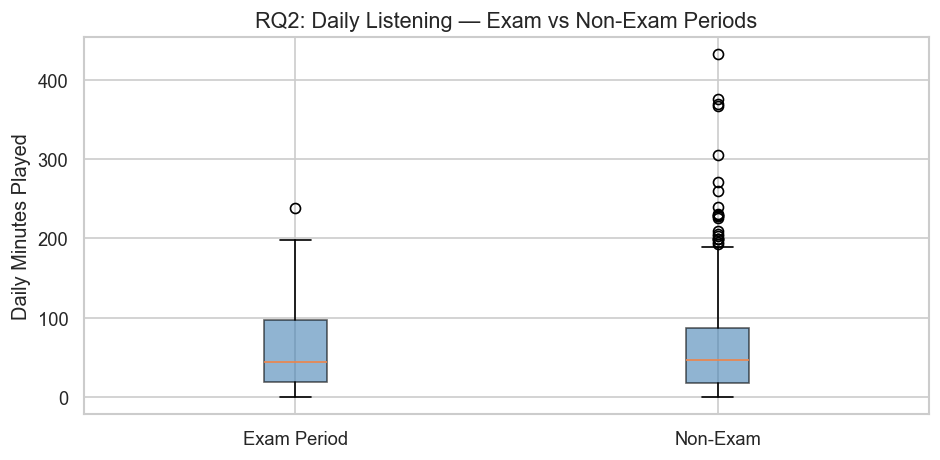

In [7]:
exam_daily    = df[df['is_exam']].groupby('date')['min_played'].sum()
nonexam_daily = df[~df['is_exam']].groupby('date')['min_played'].sum()

stat_u, pval_u = stats.mannwhitneyu(exam_daily, nonexam_daily, alternative='two-sided')
print_result('RQ2 — Daily Listening: Exam vs Non-Exam (Mann-Whitney U)', stat_u, pval_u)
print(f'  Median daily min  exam    : {exam_daily.median():.1f}')
print(f'  Median daily min  non-exam: {nonexam_daily.median():.1f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([exam_daily, nonexam_daily], labels=['Exam Period','Non-Exam'],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_ylabel('Daily Minutes Played')
ax.set_title('RQ2: Daily Listening — Exam vs Non-Exam Periods', fontsize=13)
plt.tight_layout(); plt.savefig('figures/rq2_exam.png', bbox_inches='tight'); plt.show()

## Summary of Results

In [8]:
print('='*60)
print('HYPOTHESIS TESTING SUMMARY')
print('='*60)
print()
print('H1 (Late-Night vs Daytime Valence):')
if HAS_FEATURES:
    print('  → Tested with two-sample t-test on Spotify valence scores.')
else:
    print('  → Proxy test (track duration) used — valence TBD after API enrichment.')
print()
print('H2 (Weekend vs Weekday Energy/Danceability):')
if HAS_FEATURES:
    print('  → Tested with one-sided t-test on energy and danceability.')
else:
    print('  → Proxy test (daily listening minutes) used.')
print()
print('RQ2 (Exam-period listening change):')
print('  → Tested with Mann-Whitney U on daily listening totals.')
print()
print('All figures saved to figures/')

HYPOTHESIS TESTING SUMMARY

H1 (Late-Night vs Daytime Valence):
  → Proxy test (track duration) used — valence TBD after API enrichment.

H2 (Weekend vs Weekday Energy/Danceability):
  → Proxy test (daily listening minutes) used.

RQ2 (Exam-period listening change):
  → Tested with Mann-Whitney U on daily listening totals.

All figures saved to figures/
